In [1]:
import utils
import models
import dataset
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

In [2]:
X, Y = dataset.load_data(velocity = False, downsample=50, lag = 5)
X_train, Y_train, X_test, Y_test = dataset.partition_data(X, Y, split_ratio = [.8, .2])


train: [ 2293  2294  2295 ... 11466 11467 11468], 9176
test: [   0    1    2 ... 2290 2291 2292], 2293
Epoch 1/10 | Train Loss: 0.7129 | Val Loss: 0.5334
Epoch 3/10 | Train Loss: 0.3840 | Val Loss: 0.3696
Epoch 5/10 | Train Loss: 0.3295 | Val Loss: 0.3127
Epoch 7/10 | Train Loss: 0.3124 | Val Loss: 0.2835
Epoch 9/10 | Train Loss: 0.3036 | Val Loss: 0.2800
Epoch 10/10 | Train Loss: 0.2999 | Val Loss: 0.2709
Epoch 1/10 | Train Loss: 0.9789 | Val Loss: 0.7200
Epoch 3/10 | Train Loss: 0.5170 | Val Loss: 0.5199
Epoch 5/10 | Train Loss: 0.4460 | Val Loss: 0.4505
Epoch 7/10 | Train Loss: 0.3759 | Val Loss: 0.3731
Epoch 9/10 | Train Loss: 0.3314 | Val Loss: 0.3353
Epoch 10/10 | Train Loss: 0.3231 | Val Loss: 0.3213
Epoch 1, Loss: 0.1270
Epoch 2, Loss: 0.1611
Epoch 3, Loss: 0.1097
Epoch 4, Loss: 0.1307
Epoch 5, Loss: 0.1200
Epoch 6, Loss: 0.0910
Epoch 7, Loss: 0.1368
Epoch 8, Loss: 0.1295
Epoch 9, Loss: 0.1181
Epoch 10, Loss: 0.0856
train: [    0     1     2 ... 11466 11467 11468], 9176
test: [

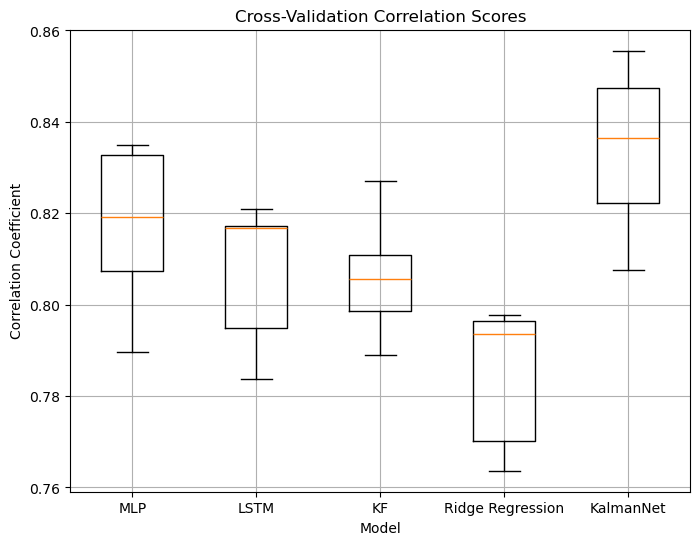

In [3]:
model_list = [models.MLP(), models.LSTM(), models.KalmanFilter(), models.RidgeRegression(), models.KalmanNet()]
labels=["MLP", "LSTM", "KF", "Ridge Regression", "KalmanNet"]

utils.cross_corr_box_plot(X, Y, model_list = model_list, labels = labels)

In [4]:
kf = models.KalmanFilter()
kf.train_model(X_train, Y_train)
kf_yhat = kf.run_model(X_test, Y_test[0, :])


In [5]:
rr = models.RidgeRegression()
rr.train_model(X_train, Y_train)
rr_yhat = rr.run_model(X_test, Y_test[0, :])


In [6]:
nn = models.LSTM()
nn.train_model(X_train, Y_train)
nn_yhat = nn.run_model(X_test)

Epoch 1/10 | Train Loss: 0.9297 | Val Loss: 0.8423
Epoch 3/10 | Train Loss: 0.5169 | Val Loss: 0.5011
Epoch 5/10 | Train Loss: 0.4523 | Val Loss: 0.4469
Epoch 7/10 | Train Loss: 0.3951 | Val Loss: 0.3914
Epoch 9/10 | Train Loss: 0.3513 | Val Loss: 0.3575
Epoch 10/10 | Train Loss: 0.3413 | Val Loss: 0.3467


In [7]:
mlp = models.MLP()
mlp.train_model(X_train, Y_train)
mlp_yhat = mlp.run_model(X_test)


Epoch 1/10 | Train Loss: 0.6963 | Val Loss: 0.5248
Epoch 3/10 | Train Loss: 0.3999 | Val Loss: 0.3834
Epoch 5/10 | Train Loss: 0.3496 | Val Loss: 0.3525
Epoch 7/10 | Train Loss: 0.3314 | Val Loss: 0.3395
Epoch 9/10 | Train Loss: 0.3228 | Val Loss: 0.3281
Epoch 10/10 | Train Loss: 0.3187 | Val Loss: 0.3297


In [8]:
knet = models.KalmanNet()
knet.train_model(X_train, Y_train)
knet_yhat, kgains = knet.run_model(X_test, Y_test[0, :], True)

Epoch 1, Loss: 0.1462
Epoch 2, Loss: 0.1599
Epoch 3, Loss: 0.1887
Epoch 4, Loss: 0.0750
Epoch 5, Loss: 0.1173
Epoch 6, Loss: 0.1121
Epoch 7, Loss: 0.1312
Epoch 8, Loss: 0.1214
Epoch 9, Loss: 0.0777
Epoch 10, Loss: 0.1056


In [9]:
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
end_plot = 500
start = 100

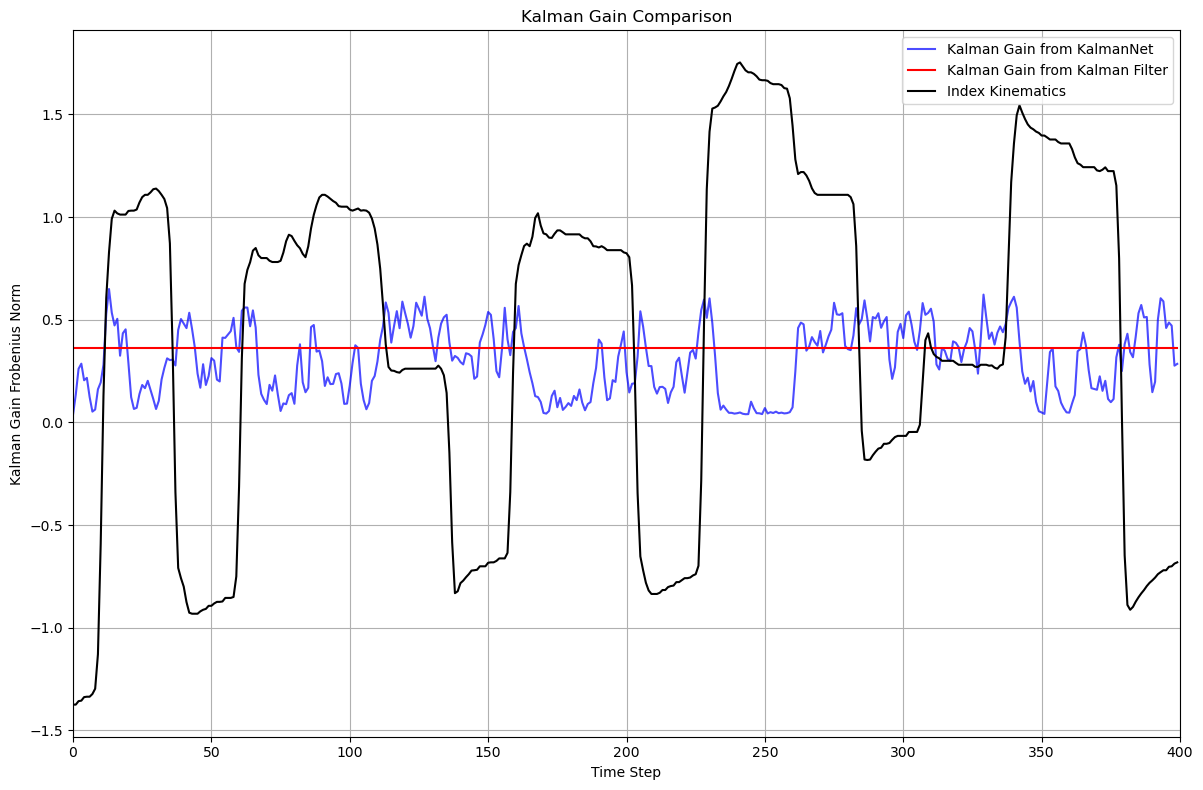

In [10]:
utils.k_gains_plot(kf.Kt_gains, kgains, Y_test, start = start, end = end_plot)

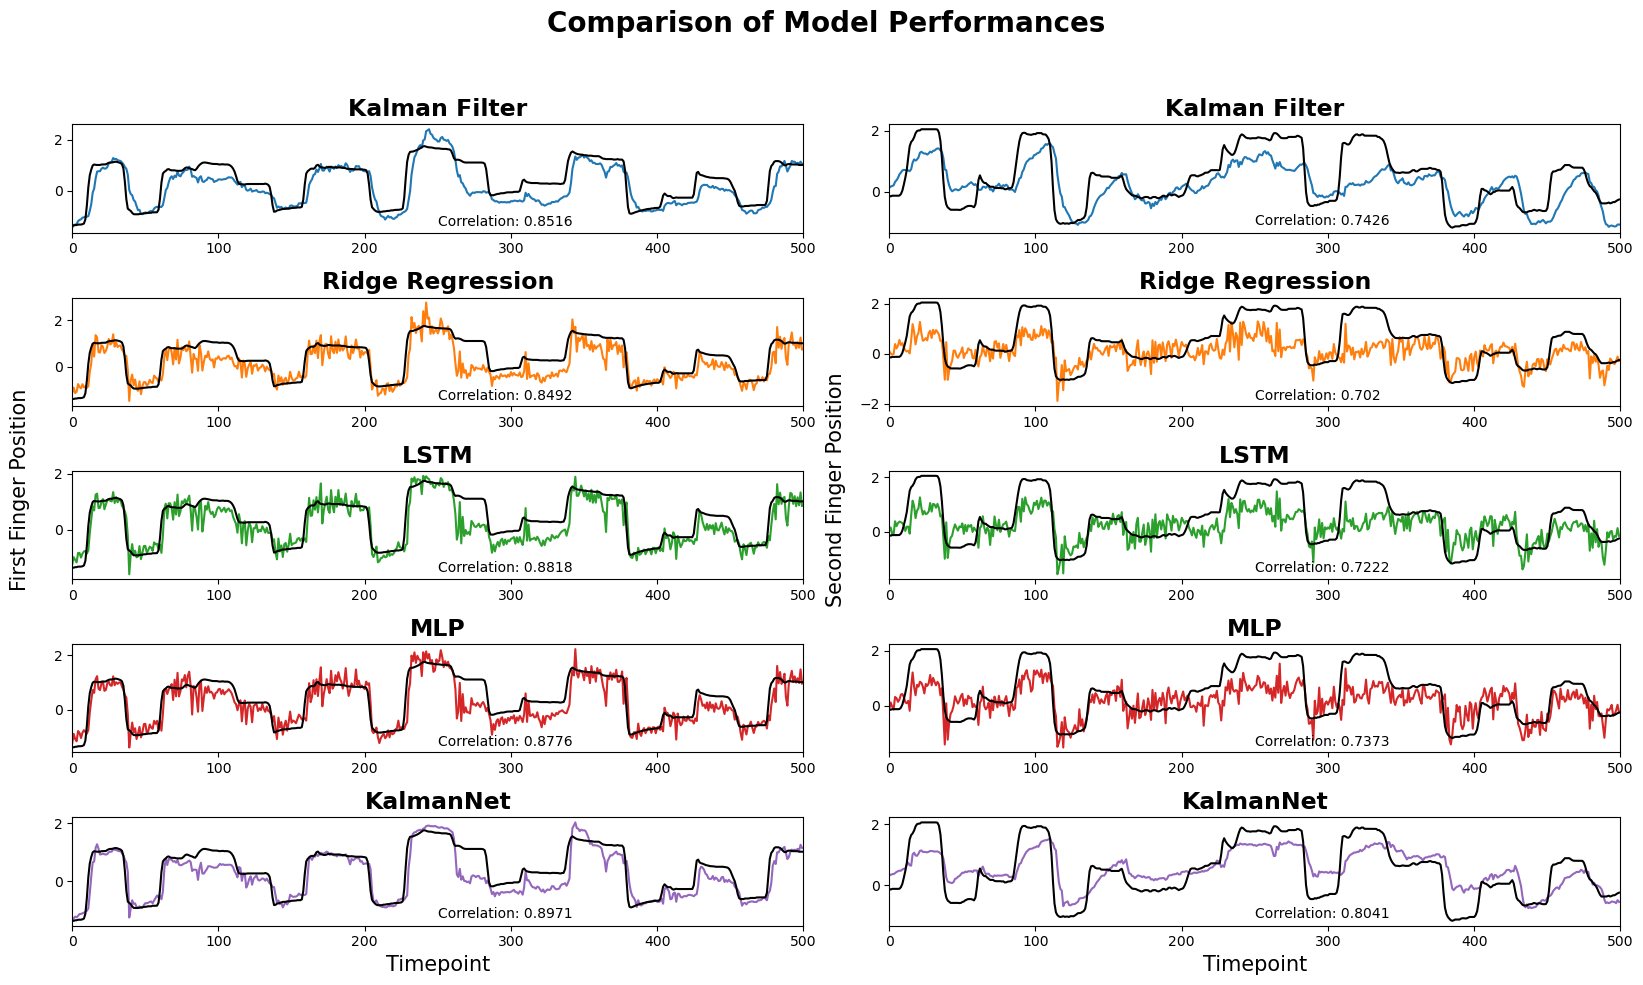

In [11]:
utils.compare_perfs(Y_test, [kf_yhat, rr_yhat, nn_yhat, mlp_yhat, knet_yhat], model_labels = ["Kalman Filter", "Ridge Regression", "LSTM", "MLP", "KalmanNet"], colors = colors, start = start, end = start + end_plot)